# Разработка программы активного шимминга магнитного поля томографа с использованием алгоритмов многомерной оптимизации

**Цель проекта:** Разработать программный комплекс для расчета токов в шиммирующих катушках, который минимизирует неоднородность главного магнитного поля $B_0$ в рабочей зоне томографа. 
Мы сравним эффективность нескольких алгоритмов математической оптимизации.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

%matplotlib inline 

import sys
sys.path.append('../')

from src.constants import MAIN_B0
from src.coils_config import coils_config
from src.physics import get_grid, generate_main_field, calculate_ppm_std
from src.optimization import precompute_unit_fields, run_optimization
from src.visualization import plot_2d_slice, plot_coils_3d

## 1. Анализ исходного (неоднородного) поля
В реальности магнитное поле томографа $B_0$ никогда не бывает идеально ровным из-за несовершенства проводников и влияния внешних факторов. 
Создадим сетку (рабочий объем) и сгенерируем начальное магнитное поле с искусственными возмущениями.

Генерация координатной сетки и исходного поля...
Среднее значение главного поля: 1.0003 Тл
Исходная неоднородность (PPM): 152.5 ppm


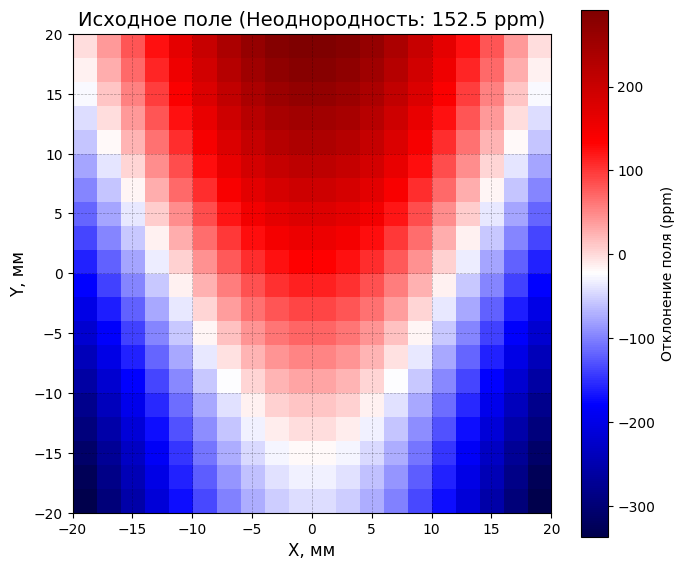

In [11]:
print("Генерация координатной сетки и исходного поля...")
grid = get_grid()
B_initial = generate_main_field(grid)

initial_ppm = calculate_ppm_std(B_initial)
print(f"Среднее значение главного поля: {np.mean(np.linalg.norm(B_initial, axis=-1)):.4f} Тл")
print(f"Исходная неоднородность (PPM): {initial_ppm:.1f} ppm")

plot_2d_slice(B_initial, title=f"Исходное поле (Неоднородность: {initial_ppm:.1f} ppm)")

## 2. Конфигурация системы шиммирования
Для компенсации неоднородностей мы используем систему из 12 локальных катушек, расположенных за пределами рабочей зоны.
Посмотрим на их расположение относительно области сканирования (зеленый куб).

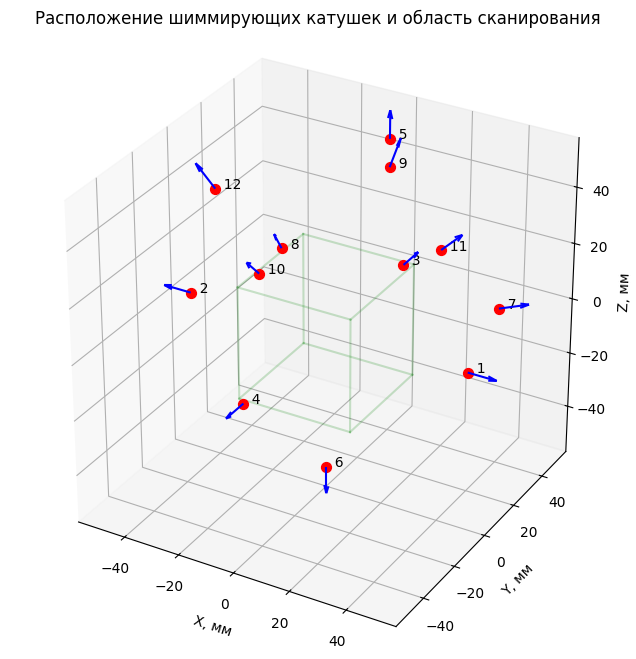

In [12]:
plot_coils_3d(coils_config)

## 3. Подготовка к оптимизации (Принцип суперпозиции)
Расчет интеграла Био-Савара — тяжелая операция. Поскольку магнитные поля складываются линейно (принцип суперпозиции), мы **один раз** посчитаем единичные поля от каждой катушки (при токе $I = 1 А$), а алгоритмы оптимизации будут просто перемножать эти массивы на векторы токов. Это ускоряет вычисления в сотни раз!

In [13]:
print("Предрасчет единичных полей катушек...")
start_time = time.time()

unit_fields = precompute_unit_fields(grid, coils_config)

calc_time = time.time() - start_time
print(f"Готово! Затрачено времени: {calc_time:.2f} сек.")

Предрасчет единичных полей катушек...
Готово! Затрачено времени: 0.20 сек.


## 4. Сравнительный тест алгоритмов многомерной оптимизации
Запустим 4 различных метода из библиотеки `scipy.optimize` и сравним их время работы и итоговое качество шимминга (чем меньше PPM, тем лучше).

1. **Nelder-Mead:** Симплексный метод (безградиентный).
2. **L-BFGS-B:** Квазиньютоновский градиентный метод.
3. **Differential Evolution:** Генетический алгоритм (ищет глобальный минимум).
4. **Dual Annealing:** Метод квантового отжига.

In [14]:
methods_to_test =["Nelder-Mead", "L-BFGS-B", "Differential Evolution", "Dual Annealing"]
results =[]
best_fields = {}

print(f"{'Метод':<25} | {'Время (сек)':<15} | {'Результат (PPM)':<15}")
print("-" * 60)

for method in methods_to_test:
    start_time = time.time()
    
    optimal_currents, final_ppm = run_optimization(B_initial, unit_fields, method_name=method)
    
    exec_time = time.time() - start_time
    
    B_compensated = B_initial + np.tensordot(optimal_currents, unit_fields, axes=1)
    best_fields[method] = B_compensated
    
    results.append({
        "Алгоритм": method,
        "Время работы (с)": round(exec_time, 3),
        "Неоднородность (PPM)": round(final_ppm, 2),
        "Токи (А)": optimal_currents
    })
    
    print(f"{method:<25} | {exec_time:<15.2f} | {final_ppm:<15.2f}")

df_results = pd.DataFrame(results).drop(columns=["Токи (А)"])
df_results.index = df_results.index + 1

Метод                     | Время (сек)     | Результат (PPM)
------------------------------------------------------------
Nelder-Mead               | 0.62            | 104.55         
L-BFGS-B                  | 0.19            | 98.14          
Differential Evolution    | 12.70           | 98.14          
Dual Annealing            | 1.85            | 98.14          


## 5. Анализ результатов
Построим столбчатые диаграммы для наглядного сравнения скорости и эффективности алгоритмов. Это отличный материал для презентации.

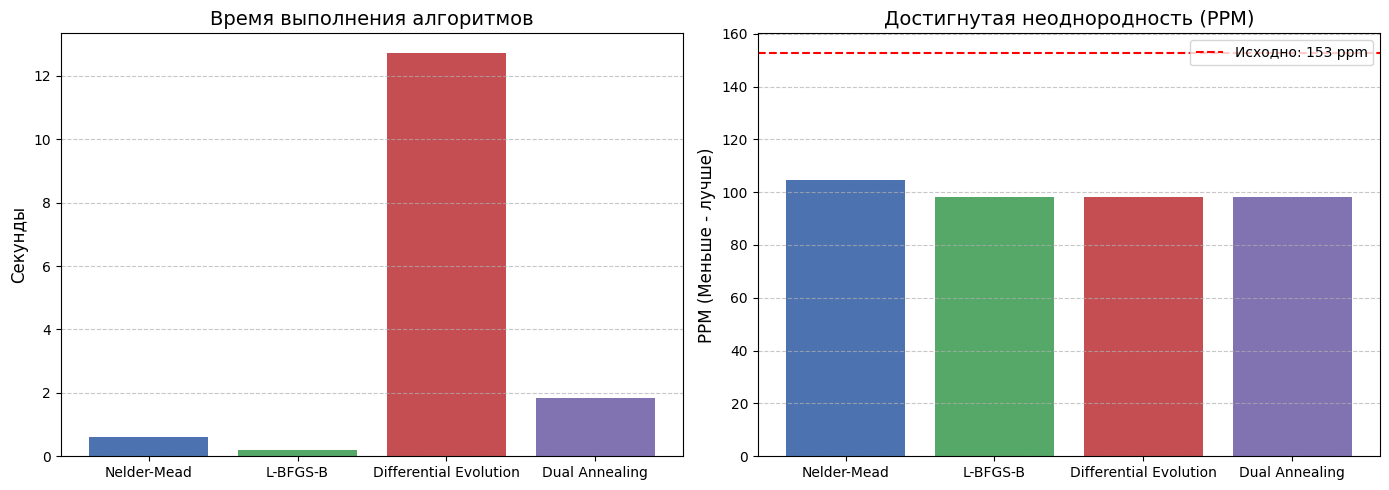

,Алгоритм,Время работы (с),Неоднородность (PPM)
1,Nelder-Mead,0.621,104.55
2,L-BFGS-B,0.193,98.14
3,Differential Evolution,12.703,98.14
4,Dual Annealing,1.852,98.14


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

algorithms = df_results["Алгоритм"]
times = df_results["Время работы (с)"]
ppms = df_results["Неоднородность (PPM)"]

# График 1: Скорость работы
ax1.bar(algorithms, times, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax1.set_title("Время выполнения алгоритмов", fontsize=14)
ax1.set_ylabel("Секунды", fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# График 2: Качество шимминга (PPM)
ax2.bar(algorithms, ppms, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax2.axhline(initial_ppm, color='red', linestyle='--', label=f'Исходно: {initial_ppm:.0f} ppm')
ax2.set_title("Достигнутая неоднородность (PPM)", fontsize=14)
ax2.set_ylabel("PPM (Меньше - лучше)", fontsize=12)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

display(df_results)

## 6. Визуализация оптимального поля
Выберем алгоритм, который показал наилучший результат (наименьший PPM), и посмотрим, как выглядит скомпенсированное поле на графике.

Лучший метод: L-BFGS-B
Снижение неоднородности: с 152.5 до 98.1 ppm

Рекомендуемые токи на катушках:
  Катушка  1:   0.07 А
  Катушка  2:   0.07 А
  Катушка  3:  -0.92 А
  Катушка  4:  -0.03 А
  Катушка  5:   1.30 А
  Катушка  6:  -0.02 А
  Катушка  7:   0.14 А
  Катушка  8:   0.14 А
  Катушка  9:  -2.00 А
  Катушка 10:  -0.09 А
  Катушка 11:   0.04 А
  Катушка 12:   0.04 А


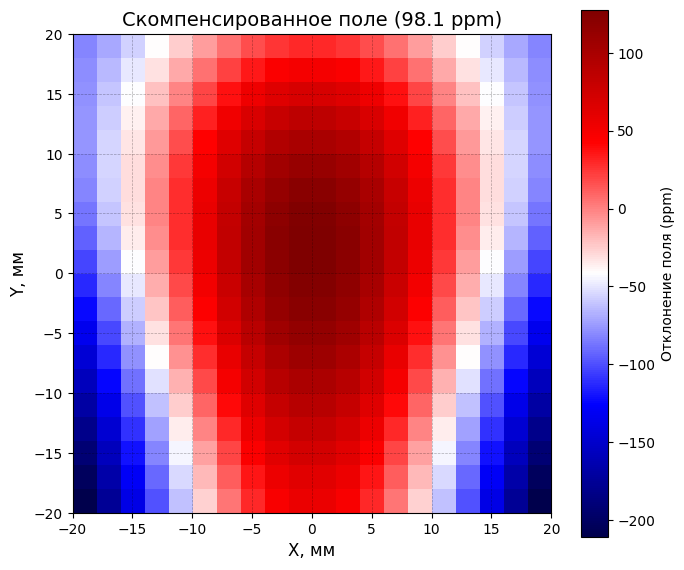

In [16]:
best_method_name = df_results.loc[df_results['Неоднородность (PPM)'].idxmin()]['Алгоритм']
best_result_data = next(item for item in results if item["Алгоритм"] == best_method_name)

print(f"Лучший метод: {best_method_name}")
print(f"Снижение неоднородности: с {initial_ppm:.1f} до {best_result_data['Неоднородность (PPM)']:.1f} ppm\n")

print("Рекомендуемые токи на катушках:")
for i, current in enumerate(best_result_data["Токи (А)"]):
    print(f"  Катушка {i+1:2d}: {current:>6.2f} А")

plot_2d_slice(best_fields[best_method_name], 
              title=f"Скомпенсированное поле ({best_result_data['Неоднородность (PPM)']:.1f} ppm)")